### RE ROUTE

In [1]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

### MANIFESTO

In [2]:
from scripts.utils.logger import logger

In [3]:
logger_params = {
    "main_folder": "/home/think/Desktop/MOCK",
    "experiment_name": "Consolidation",
    "date": "2025-09-07",
    "iteration": 69,
    "description": (
        "Se va a consolidar la funcion generadora "
        " de sistemas caoticos, esta sera modular."
        "Es decir, vamos a hacerlo solo para Lorenz con la posibilidad de solo tener"
        "que cambiar la defincion al principio"
        "con dos modos de generacion"
        "- Mismos params, diferentes i.c."
        "- Diferentes params, mismas i.c"
    )
}

In [4]:
exp_folder, manifesto_path = logger(logger_params)
print(f"Experiment folder created at: {exp_folder}")
print(f"Manifesto written to: {manifesto_path}")

Experiment folder created at: /home/think/Desktop/MOCK/Consolidation_2025-09-07_iter69
Manifesto written to: /home/think/Desktop/MOCK/Consolidation_2025-09-07_iter69/manifesto.txt


### Single trajectory

In [5]:
from scripts.data_generation.binder import Binder
from scripts.utils.plastic_surgeon import from_sol_to_df
import numpy as np
from scipy.integrate import solve_ivp
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem

In [6]:
# Define model and params
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder(f"scripts.systems.{model_name}", model_name, params)
binder.import_module()      # will reload if module is already in memory
model_fixed = binder.fixer()

# Define time span 
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 100000)
# Define initial conditions
y0 = np.array([0.1, 0.1, 0.1])

# Solve each system
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()

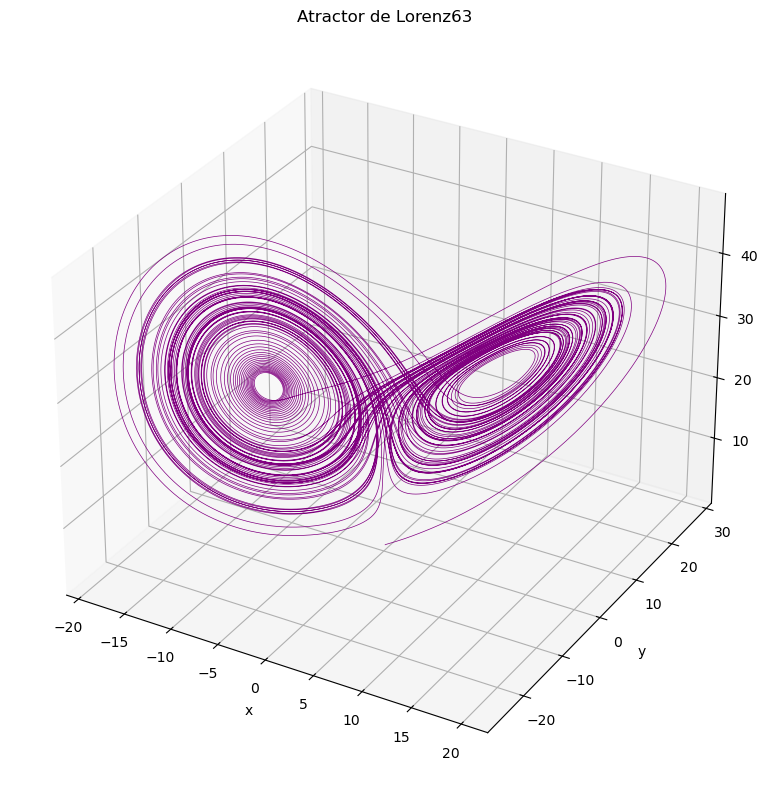

In [7]:
_ = ds1.plot(kind = '3d')

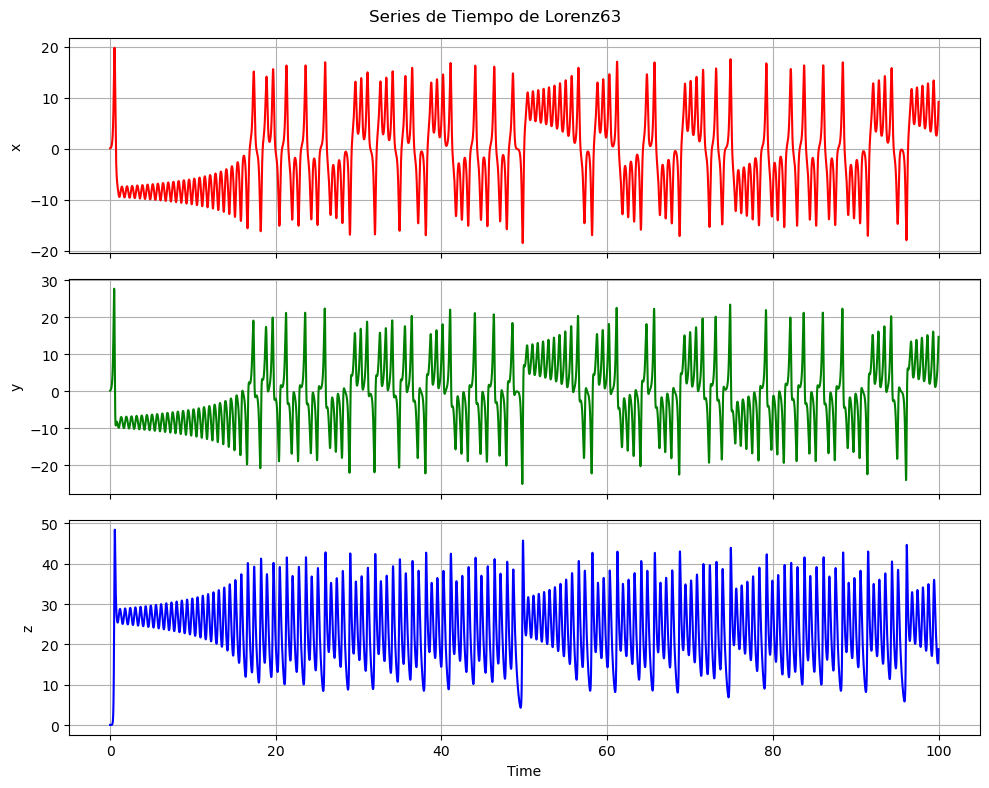

In [8]:
_ = ds1.plot(kind = 'series')

### Largest lyapunov exponent, the naive way

In [9]:
from scripts.data_generation.binder import Binder
from scripts.utils.plastic_surgeon import from_sol_to_df
import numpy as np
from scipy.integrate import solve_ivp
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem

In [10]:
# Define model and params
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder(f"scripts.systems.{model_name}", model_name, params)
binder.import_module()      # will reload if module is already in memory
model_fixed = binder.fixer()

# Define time span 
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 100000)
# Define initial conditions
y0 = np.array([0.1, 0.1, 0.1])
eps = 1e-8
y0_perturbed = y0 + eps

# Solve each system
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()
ds2 = DynamicalSystem(model_fixed, y0_perturbed, t_eval, notebook=True)
_ = ds2.solve()

In [11]:
# Compute full 3D separation
delta = np.linalg.norm(ds1.solution.y - ds2.solution.y, axis=0)
delta0 = delta[0]  # should be close to eps

log_delta = np.log(delta / delta0)

t = ds1.solution.t

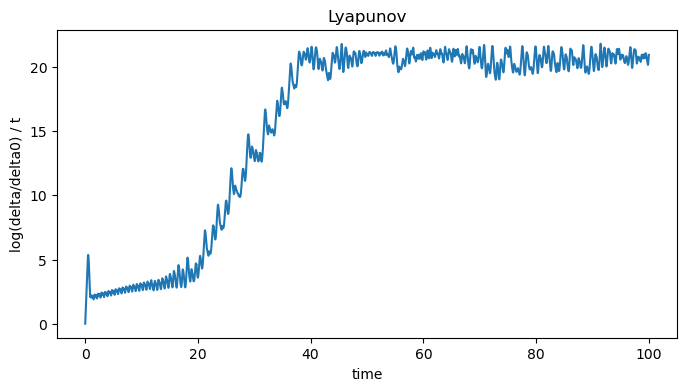

In [12]:
running_lambda = np.log(delta / delta0)

plt.figure(figsize=(8,4))
plt.plot(t, running_lambda)
plt.xlabel('time')
plt.ylabel('log(delta/delta0) / t')
plt.title('Lyapunov')
plt.show()

In [13]:
# Define transient cutoff and linear fitting window
transient = 17
fit_end = 40

# Select the fitting region after transient
linear_idx = (t > transient) & (t < fit_end)
t_linear = t[linear_idx]
delta_linear = delta[linear_idx]

# Fit a line to log(delta) to get slope = Lyapunov exponent
slope, intercept = np.polyfit(t_linear, np.log(delta_linear / delta0), 1)
lambda_max = slope
print("Approximate largest Lyapunov exponent:", lambda_max)

Approximate largest Lyapunov exponent: 0.8281784423890675


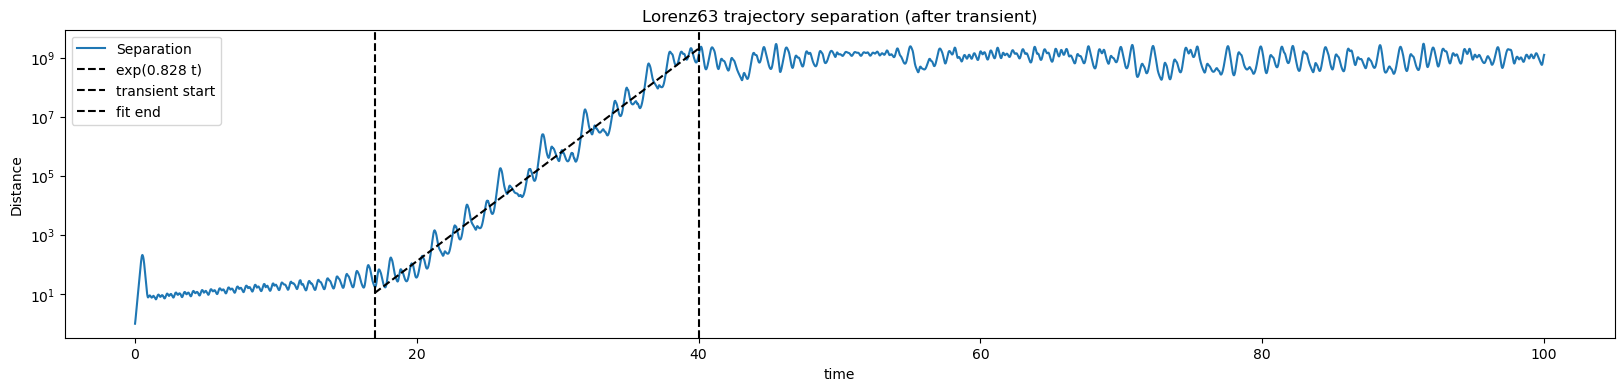

In [14]:
# Plot
plt.figure(figsize=(20,4))
plt.semilogy(t, delta / delta0, label='Separation')
plt.semilogy(t_linear, np.exp(intercept + slope*t_linear), 'k--', 
             label=f'exp({lambda_max:.3f} t)')

# Add vertical lines for transient and fit end
plt.axvline(transient, color='k', linestyle='--', label='transient start')
plt.axvline(fit_end, color='k', linestyle='--', label='fit end')

plt.xlabel('time')
plt.ylabel('Distance')
plt.title('Lorenz63 trajectory separation (after transient)')
plt.legend()
plt.show()


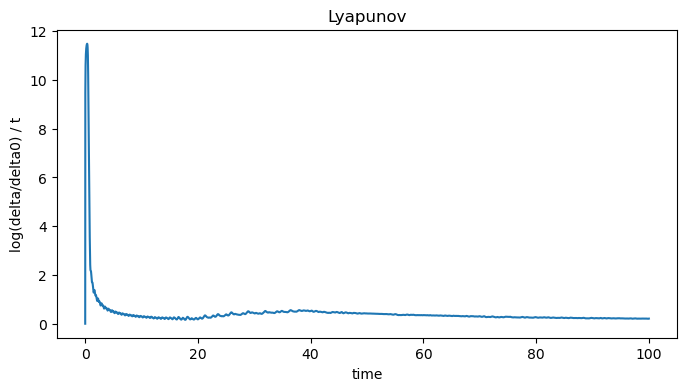

In [15]:
# avoid t=0
t_nonzero = t.copy()
t_nonzero[0] = t[1]

running_lambda = np.log(delta / delta0) / t_nonzero

plt.figure(figsize=(8,4))
plt.plot(t, running_lambda)
plt.xlabel('time')
plt.ylabel('log(delta/delta0) / t')
plt.title('Lyapunov')
plt.show()


### Largest Lyapunov exponent, a not so naive way

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_generation.binder import Binder
from scripts.utils.plastic_surgeon import from_sol_to_df
from scripts.data_generation.tsdg import DynamicalSystem

# --- Define model and parameters ---
model_name = 'lorenz63'
sigma = 10
beta = 8/3
rho = 28
params = (sigma, beta, rho)

# Load and fix model
binder = Binder(f"scripts.systems.{model_name}", model_name, params)
binder.import_module()
model_fixed = binder.fixer()

# --- Initial condition and small perturbation ---
y0 = np.array([0.1, 0.1, 0.1])
eps = 1e-8
y0_perturbed = y0 + eps 

# --- Time span ---
t_span = (0, 100)
n_steps = 100000
t_eval = np.linspace(t_span[0], t_span[1], n_steps)

# --- Compute trajectories ---
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook=True)
_ = ds1.solve()

ds2 = DynamicalSystem(model_fixed, y0_perturbed, t_eval, notebook=True)
_ = ds2.solve()

/tmp/ipykernel_7663/1941878893.py:7: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.semilogy(distance_trj)


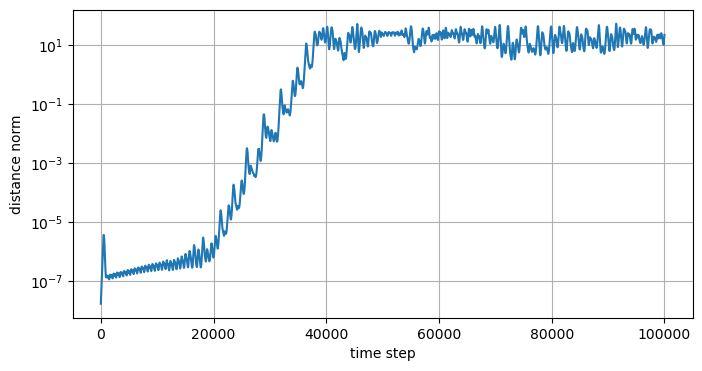

In [ ]:
# --- Compute distance between trajectories ---
distance_trj = np.linalg.norm(ds2.solution.y - ds1.solution.y, axis=0)

# --- Plot distance evolution ---
plt.figure(figsize=(8,4))
plt.axhline(y = 0, linestyle='--')
plt.semilogy(distance_trj)
plt.xlabel("time step")
plt.ylabel("distance norm")

plt.grid()
plt.show()

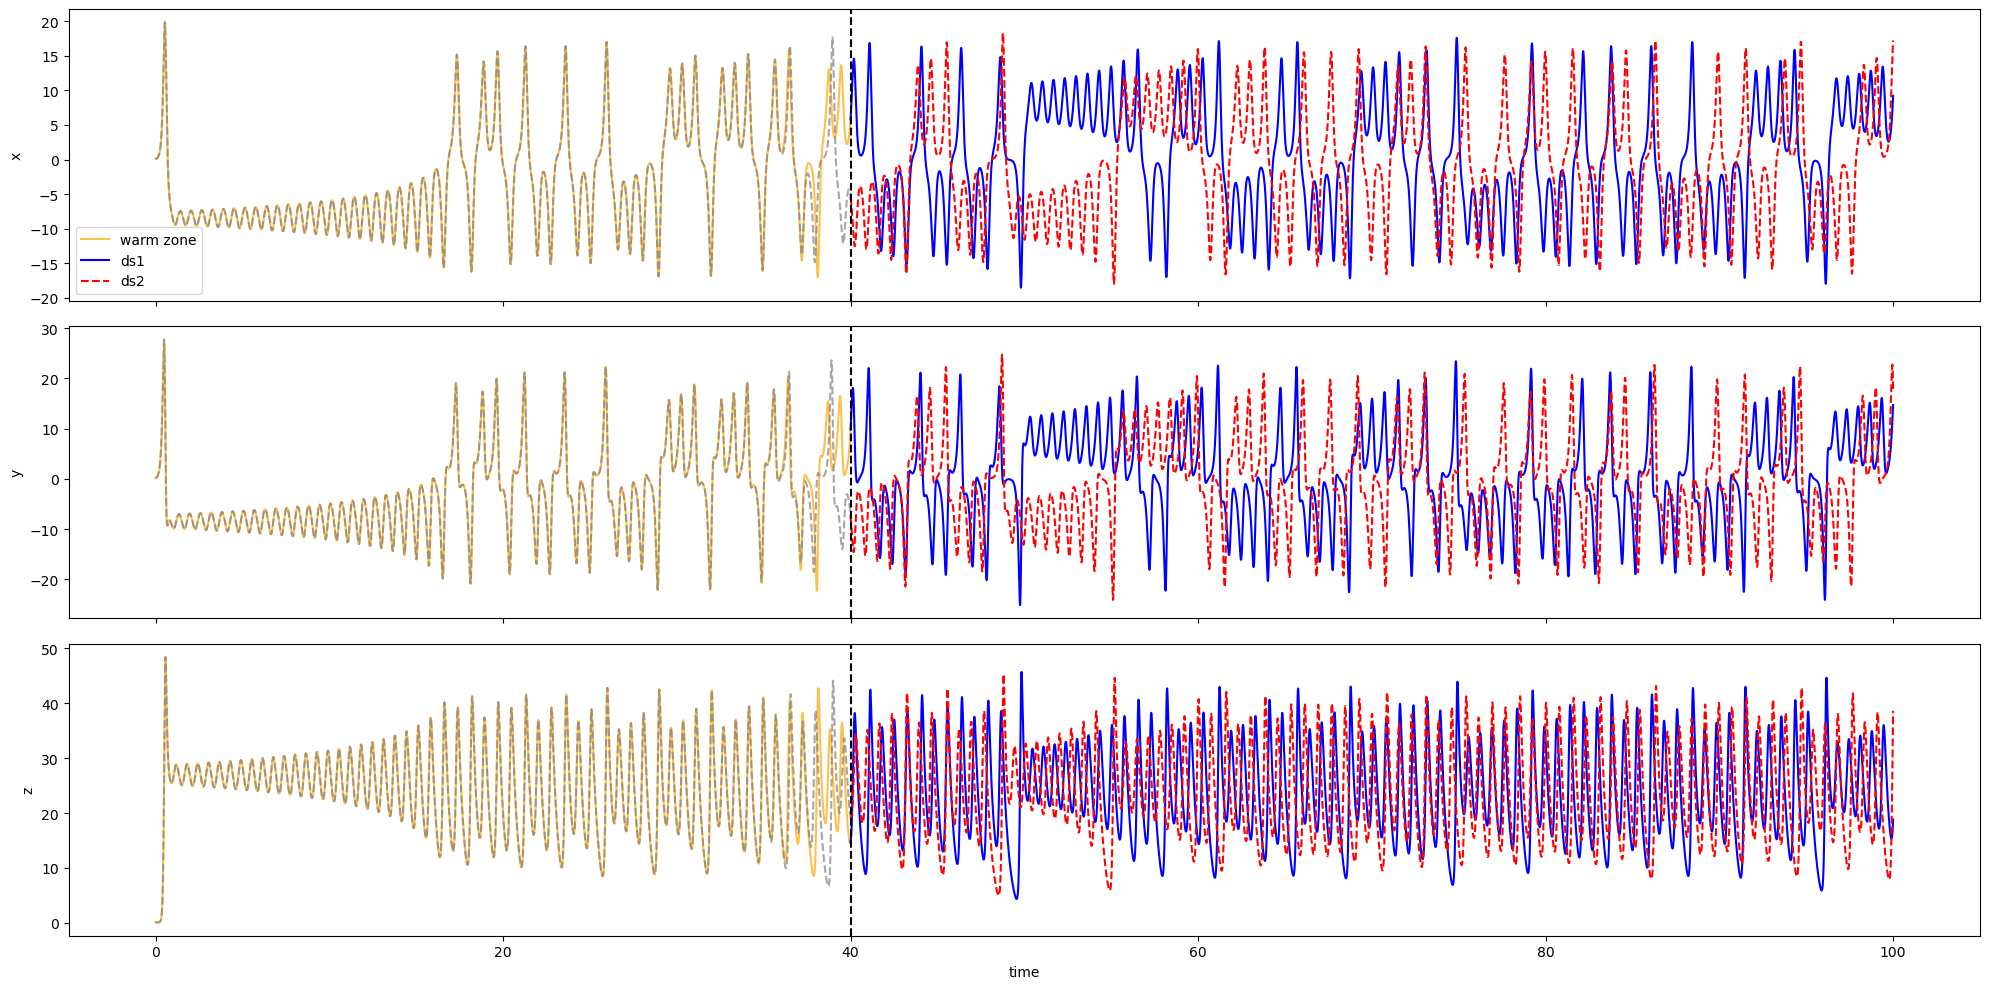

In [168]:
# pick your cutoff time
start_cut = 20.0
end_cut = 40.0


# t_cut = 38.0
cut_idx = np.searchsorted(t_eval, end_cut)

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)
labels = ['x', 'y', 'z']

for dim in range(3):

    # --- gray warm zone (before cutoff) ---
    axes[dim].plot(
        t_eval[:cut_idx],
        ds1.solution.y[dim, :cut_idx],
        color='orange', alpha=0.7,
        label='warm zone' if dim == 0 else None
    )
    axes[dim].plot(
        t_eval[:cut_idx],
        ds2.solution.y[dim, :cut_idx],
        linestyle='--',
        color='gray', alpha=0.7
    )

    # --- real colors (after cutoff) ---
    axes[dim].plot(
        t_eval[cut_idx:],
        ds1.solution.y[dim, cut_idx:],
        color='blue',
        label='ds1' if dim == 0 else None
    )
    axes[dim].plot(
        t_eval[cut_idx:],
        ds2.solution.y[dim, cut_idx:],
        color='red',
        linestyle='--',
        label='ds2' if dim == 0 else None
    )

    # vertical line
    axes[dim].axvline(end_cut, color='black', linestyle='--')

    axes[dim].set_ylabel(labels[dim])

axes[-1].set_xlabel("time")
axes[0].legend()
plt.tight_layout()
plt.show()


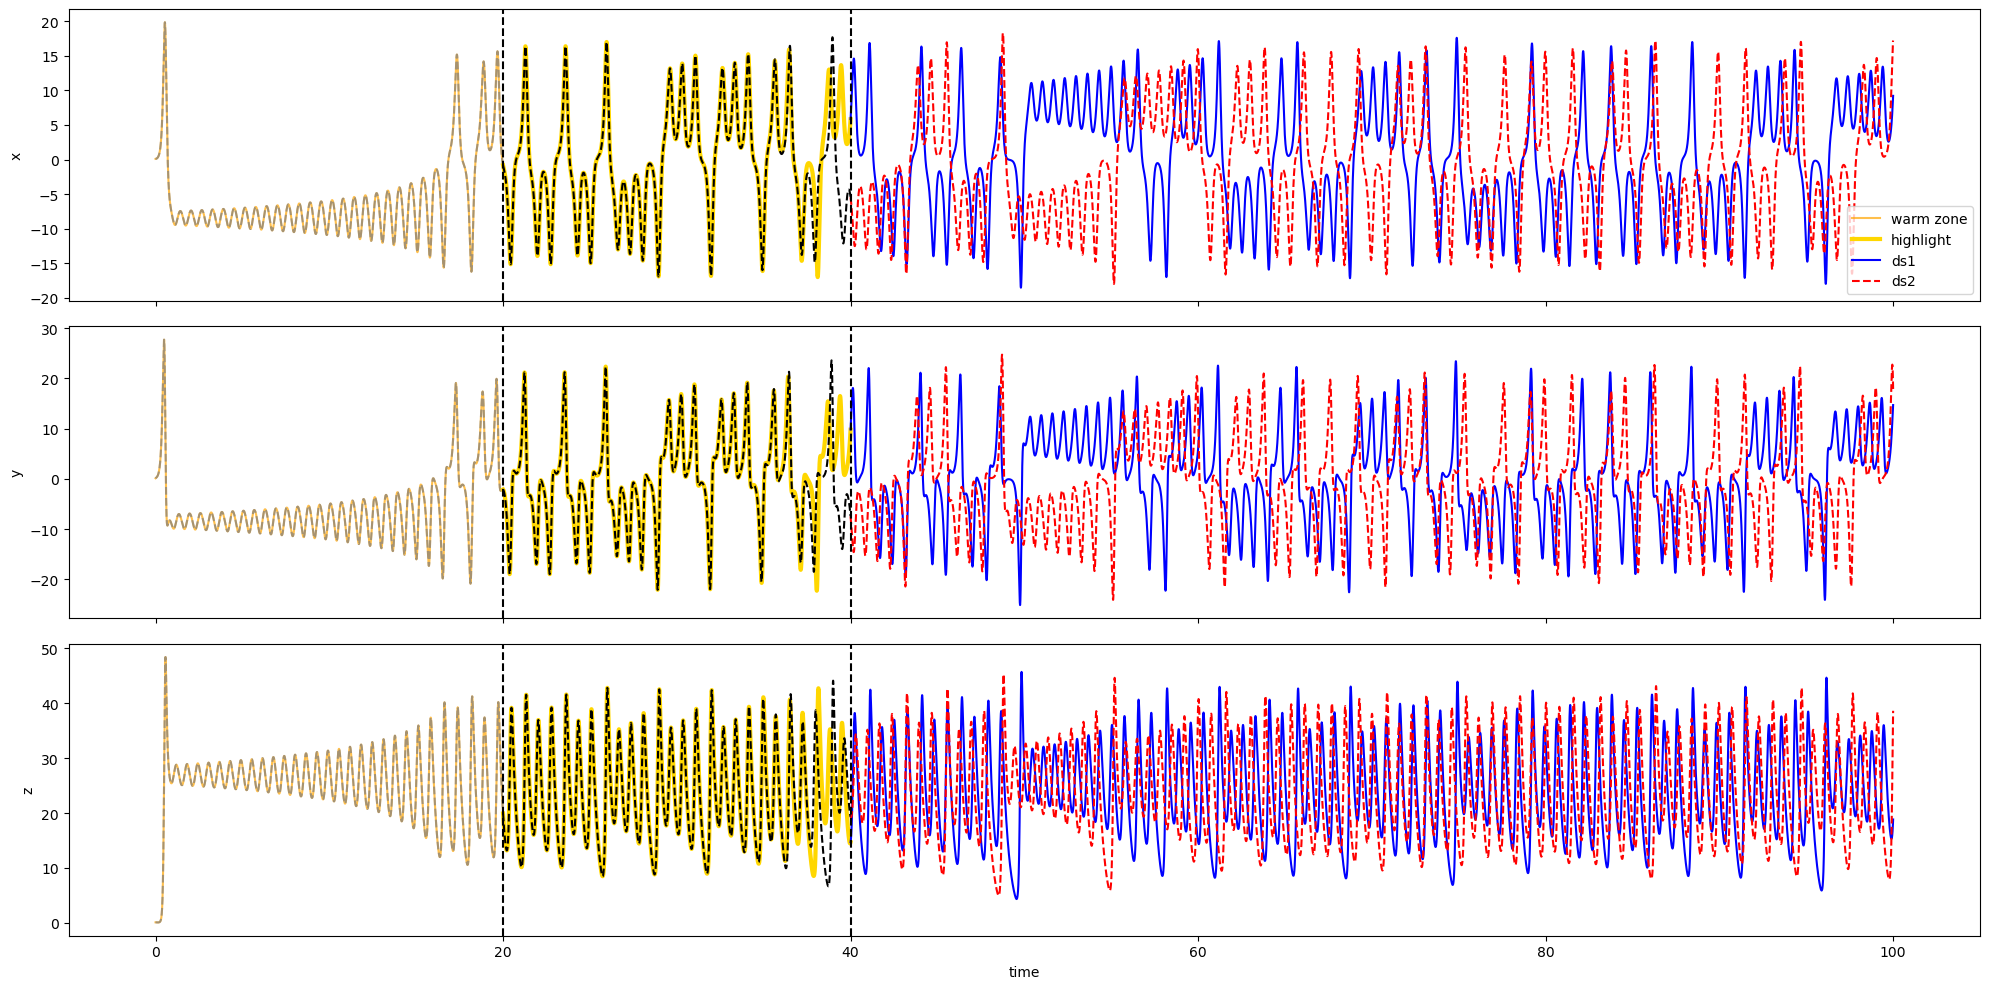

In [ ]:
# pick your cutoff time
start_cut = 20.0
end_cut = 40.0

i_start = np.searchsorted(t_eval, start_cut)
i_end   = np.searchsorted(t_eval, end_cut)

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)
labels = ['x', 'y', 'z']

for dim in range(3):

    # -------- zone 1: before start_cut (your original warm zone colors) --------
    axes[dim].plot(
        t_eval[:i_start],
        ds1.solution.y[dim, :i_start],
        color='orange', alpha=0.7,
        label='warm zone' if dim == 0 else None
    )
    axes[dim].plot(
        t_eval[:i_start],
        ds2.solution.y[dim, :i_start],
        linestyle='--',
        color='gray', alpha=0.7
    )

    # -------- zone 2: between start_cut and end_cut (highlight zone) --------
    axes[dim].plot(
        t_eval[i_start:i_end],
        ds1.solution.y[dim, i_start:i_end],
        color='gold', linewidth=3,
        label='highlight' if dim == 0 else None
    )
    axes[dim].plot(
        t_eval[i_start:i_end],
        ds2.solution.y[dim, i_start:i_end],
        linestyle='--',
        color='black', linewidth=1.5
    )

    # -------- zone 3: after end_cut (your original post-cut colors) --------
    axes[dim].plot(
        t_eval[i_end:],
        ds1.solution.y[dim, i_end:],
        color='blue',
        label='ds1' if dim == 0 else None
    )
    axes[dim].plot(
        t_eval[i_end:],
        ds2.solution.y[dim, i_end:],
        color='red',
        linestyle='--',
        label='ds2' if dim == 0 else None
    )

    # vertical lines
    axes[dim].axvline(start_cut, color='black', linestyle='--')
    axes[dim].axvline(end_cut, color='black', linestyle='--')

    axes[dim].set_ylabel(labels[dim])

axes[-1].set_xlabel("time")
axes[0].legend()
plt.tight_layout()

plt.show()


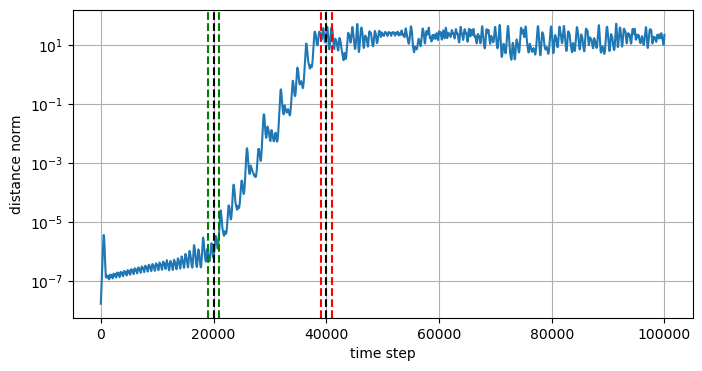

In [152]:
start_cut = 20000
end_cut = 40000

spacing = 1000
num_lines_each_side = 1

# Compute line positions
start_lines_left = [start_cut - spacing * i for i in range(num_lines_each_side, 0, -1)]
start_lines_right = [start_cut + spacing * i for i in range(1, num_lines_each_side + 1)]
start_all_lines = start_lines_left + [start_cut] + start_lines_right

# Compute line positions
end_lines_left = [end_cut - spacing * i for i in range(num_lines_each_side, 0, -1)]
end_lines_right = [end_cut + spacing * i for i in range(1, num_lines_each_side + 1)]
end_all_lines = end_lines_left + [end_cut] + end_lines_right

# --- Plot distance evolution ---
plt.figure(figsize=(8,4))
plt.semilogy(distance_trj)

# Plot all vertical lines with colors
for x in start_all_lines:
    color = 'k' if x == start_cut else 'green'  # black for obo, red for others
    plt.axvline(x=x, color=color, linestyle='--')

# Plot all vertical lines with colors
for x in end_all_lines:
    color = 'k' if x == end_cut else 'r'  # black for obo, red for others
    plt.axvline(x=x, color=color, linestyle='--')   

#plt.axhline(y = 10e-18, linestyle='--')
plt.xlabel("time step")
plt.ylabel("distance norm")
#plt.xlim(0,50000)
plt.grid()
plt.show()

In [153]:
# --- Lyapunov exponent via linear fit ---
# Choose first portion for linear approximation
time_points = np.arange(len(distance_trj)) * (t_eval[1] - t_eval[0])
lyapunov_exponent, log_offset = np.polyfit(time_points[start_cut:end_cut], np.log(distance_trj[start_cut:end_cut]), 1)
print("Approximate largest Lyapunov exponent:", lyapunov_exponent)

Approximate largest Lyapunov exponent: 0.8419709681026766


### Idk, LLE bonus stuff

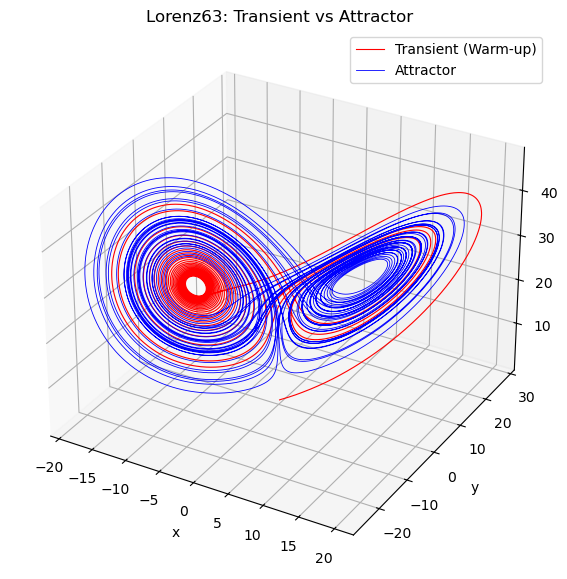

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # needed for 3D projection

from scripts.data_generation.binder import Binder
from scripts.data_generation.tsdg import DynamicalSystem

# --- Define model and parameters ---
model_name = 'lorenz63'
sigma = 10
beta = 8/3
rho = 28
params = (sigma, beta, rho)

binder = Binder(f"scripts.systems.{model_name}", model_name, params)
binder.import_module()
model_fixed = binder.fixer()

# --- Time spans ---
t_warm = np.linspace(0, 20, 20000)      # warm-up (shorter is enough)
t_attractor = np.linspace(0, 50, 50000) # real attractor

# --- Initial condition ---
y0 = np.array([0.1, 0.1, 0.1])

# --- Warm-up trajectory ---
ds_warm = DynamicalSystem(model_fixed, y0, t_warm, notebook=True)
_ = ds_warm.solve()

# last point on attractor
y0_warmed = ds_warm.solution.y[:, -1]

# --- Actual attractor trajectory ---
ds_attr = DynamicalSystem(model_fixed, y0_warmed, t_attractor, notebook=True)
_ = ds_attr.solve()

# Extract data
x_w, y_w, z_w = ds_warm.solution.y
x_a, y_a, z_a = ds_attr.solution.y

# --- PLOT ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x_w, y_w, z_w, color='red', linewidth=0.8, label='Transient (Warm-up)')
ax.plot(x_a, y_a, z_a, color='blue', linewidth=0.6, label='Attractor')

ax.set_title("Lorenz63: Transient vs Attractor")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()

plt.show()


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_generation.binder import Binder
from scripts.data_generation.tsdg import DynamicalSystem

# --- Define model and parameters ---
model_name = 'lorenz63'
sigma = 10
beta = 8/3
rho = 27
params = (sigma, beta, rho)

# --- Load and fix model ---
binder = Binder(f"scripts.systems.{model_name}", model_name, params)
binder.import_module()
model_fixed = binder.fixer()  # partial(lorenz63, sigma, beta, rho)
# model_fixed(t, state) now only needs t and state

# --- Initial condition and perturbation ---
y0 = np.array([1, 1, 1])
eps = 1e-8

# --- Time span ---
t_span = (0, 500)
n_steps = 50000
t_eval = np.linspace(t_span[0], t_span[1], n_steps)
# dt = t_eval[1] - t_eval[0]

dt = t_eval[1] - t_eval[0]
dt = np.floor(dt*100)/100


# --- Add solve_rk4 to DynamicalSystem ---
def solve_rk4(self, dt):
    """Fixed-step RK4 integration compatible with Binder-fixed functions."""
    y = [self.y0]
    t_points = self.t
    f = self.f  # expects f(t, state)
    for i in range(1, len(t_points)):
        u = y[-1]
        t_curr = t_points[i-1]

        k1 = np.array(f(t_curr, u))
        k2 = np.array(f(t_curr + 0.5*dt, u + 0.5*dt*k1))
        k3 = np.array(f(t_curr + 0.5*dt, u + 0.5*dt*k2))
        k4 = np.array(f(t_curr + dt, u + dt*k3))

        y_next = u + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
        y.append(y_next)

    y = np.array(y).T
    self.solution = type('Solution', (), {})()
    self.solution.t = t_points
    self.solution.y = y
    return self.solution

# attach it to DynamicalSystem
DynamicalSystem.solve_rk4 = solve_rk4

# --- Warm-up trajectory ---
ds_warm = DynamicalSystem(model_fixed, y0, t_eval, notebook=True)
_ = ds_warm.solve_rk4(dt)
y0_warmed = ds_warm.solution.y[:, -1]

# --- Perturbed initial condition ---
y0_perturbed = y0_warmed + eps 
# y0_perturbed = y0_warmed + eps * (2*np.random.rand(3)-1)

# --- Compute trajectories ---
ds1 = DynamicalSystem(model_fixed, y0_warmed, t_eval, notebook=True)
_ = ds1.solve_rk4(dt)

ds2 = DynamicalSystem(model_fixed, y0_perturbed, t_eval, notebook=True)
_ = ds2.solve_rk4(dt)

# --- Compute distance between trajectories ---
distance_trj = np.linalg.norm(ds2.solution.y - ds1.solution.y, axis=0)

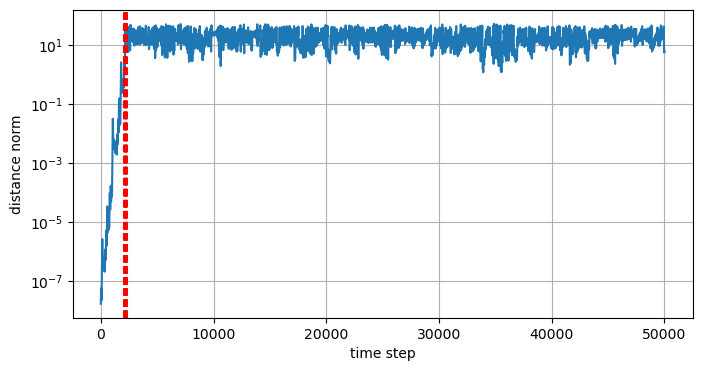

In [ ]:
obo = 2200
spacing = 50
num_lines_each_side = 2

# Compute line positions
lines_left = [obo - spacing * i for i in range(num_lines_each_side, 0, -1)]
lines_right = [obo + spacing * i for i in range(1, num_lines_each_side + 1)]
all_lines = lines_left + [obo] + lines_right

# --- Plot distance evolution ---
plt.figure(figsize=(8,4))
plt.semilogy(distance_trj)

# Plot all vertical lines with colors
for x in all_lines:
    color = 'k' if x == obo else 'r'  # black for obo, red for others
    plt.axvline(x=x, color=color, linestyle='--')

plt.xlabel("time step")
plt.ylabel("distance norm")
plt.xlim(0,5000)
plt.grid()
plt.show()

In [17]:
# --- Lyapunov exponent via linear fit ---
fit_end_idx = 2150
time_points = np.arange(len(distance_trj)) * dt
lyapunov_exponent, log_offset = np.polyfit(time_points[:fit_end_idx], np.log(distance_trj[:fit_end_idx]), 1)
print("Approximate largest Lyapunov exponent:", lyapunov_exponent)

Approximate largest Lyapunov exponent: 0.8352827852063572


In [18]:
print(dt)

0.01


### Lyapunov para distintos rho

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Original parameters
sigma = 10
beta = 8/3
rho_values = np.linspace(0, 100, 1000)  
params_base = (sigma, beta, None)    # placeholder for rho


# --- Initial condition and perturbation ---
y0 = np.array([1, 1, 1])
eps = 1e-8

# --- Time span ---
t_span = (0, 200)
n_steps = 20000
t_eval = np.linspace(t_span[0], t_span[1], n_steps)


# Store Lyapunov exponents
lambda_max_list = []

# Loop over rho
for rho in rho_values:
    # Update model with new rho
    params = (sigma, beta, rho)
    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()
    
    # Solve trajectories (keep y0 same)
    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    _ = ds1_rho.solve()
    
    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    _ = ds2_rho.solve()
    
    # Compute separation
    delta = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)
    t = ds1_rho.solution.t
    
    # Linear fit window (after transient)
    linear_idx = (t > transient) & (t < fit_end)
    t_linear = t[linear_idx]
    delta_linear = delta[linear_idx]
    
    # Linear fit of log(delta) to get Lyapunov exponent
    slope, intercept = np.polyfit(t_linear, np.log(delta_linear), 1)
    lambda_max_list.append(slope)

In [ ]:
# --- Compute distance between trajectories ---
distance_trj = np.linalg.norm(ds2.solution.y - ds1.solution.y, axis=0)

# --- Plot distance evolution ---
plt.figure(figsize=(8,4))
plt.axhline(y = 0, linestyle='--')
plt.semilogy(distance_trj)
plt.xlabel("time step")
plt.ylabel("distance norm")

plt.grid()
plt.show()

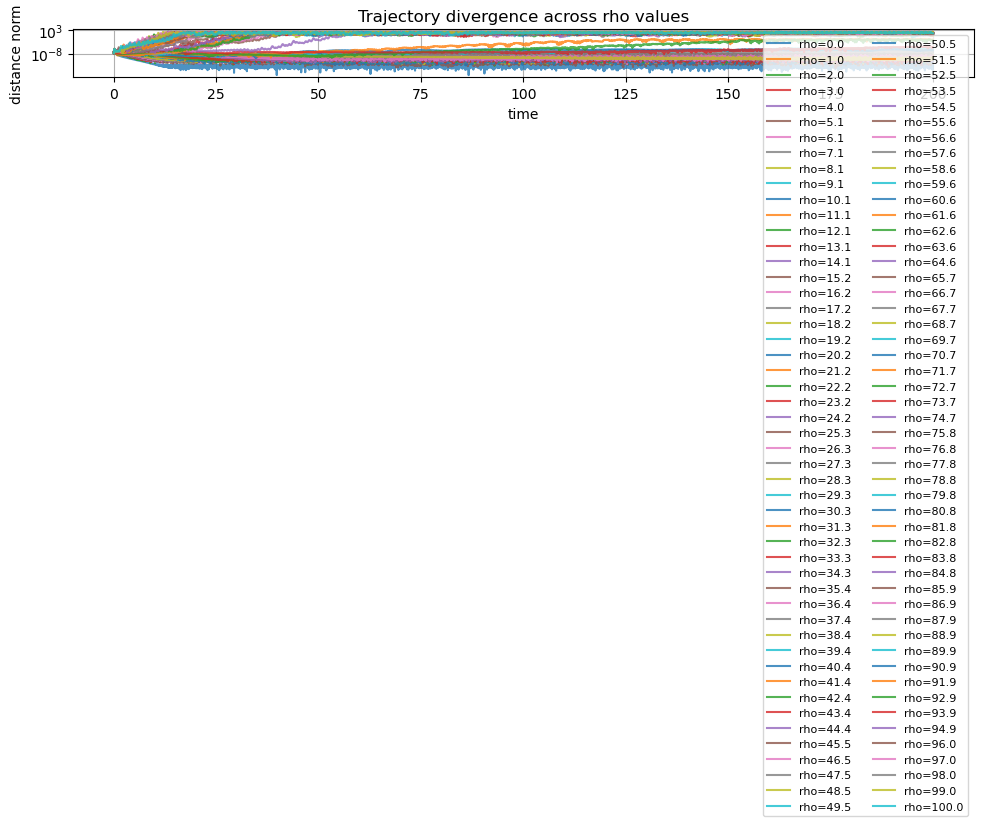

In [178]:
import numpy as np
import matplotlib.pyplot as plt

# pick about 10 values instead of thousands
rho_sample = np.linspace(0, 100, 100)  

plt.figure(figsize=(10,5))

for rho in rho_sample:
    params = (sigma, beta, rho)
    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()

    # solve unperturbed
    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    ds1_rho.solve()

    # solve perturbed
    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    ds2_rho.solve()

    # compute distance curve
    dist = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)

    # plot each trajectory separation
    plt.semilogy(t_eval, dist, alpha=0.8, label=f"rho={rho:.1f}")

plt.xlabel("time")
plt.ylabel("distance norm")
plt.title("Trajectory divergence across rho values")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


In [182]:
import os
import numpy as np
import matplotlib.pyplot as plt

# folder to save images
save_path = f"{exp_folder}/lyap_images"

# create folder if it doesn't exist
os.makedirs(save_path, exist_ok=True)

rho_sample = np.linspace(0, 100, 100)   # choose 10 values (or whatever you want)

for i, rho in enumerate(rho_sample):

    params = (sigma, beta, rho)
    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()

    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    ds1_rho.solve()

    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    ds2_rho.solve()

    dist = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)

    # --- plot ---
    plt.figure(figsize=(8,4))
    plt.semilogy(t_eval, dist)
    plt.grid(True)
    plt.xlabel("time")
    plt.ylabel("distance")
    plt.title(f"Iteration {i} — rho={rho:.3f}")

    # --- save ---
    filename = f"{i}.png"
    filepath = os.path.join(save_path, filename)
    plt.savefig(filepath, dpi=200, bbox_inches='tight')

    plt.close()   # close figure so memory doesn’t explode


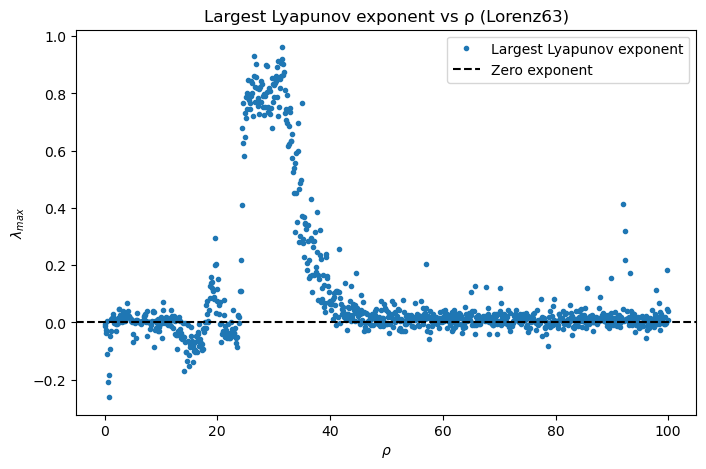

In [175]:
# Plot Lyapunov exponent vs rho
plt.figure(figsize=(8,5))
plt.plot(rho_values, lambda_max_list, '.', label='Largest Lyapunov exponent')
plt.axhline(0, color='k', linestyle='--', label='Zero exponent')
plt.xlabel(r'$\rho$')
plt.ylabel(r'$\lambda_{max}$')
plt.title('Largest Lyapunov exponent vs ρ (Lorenz63)')
plt.legend()
plt.show()

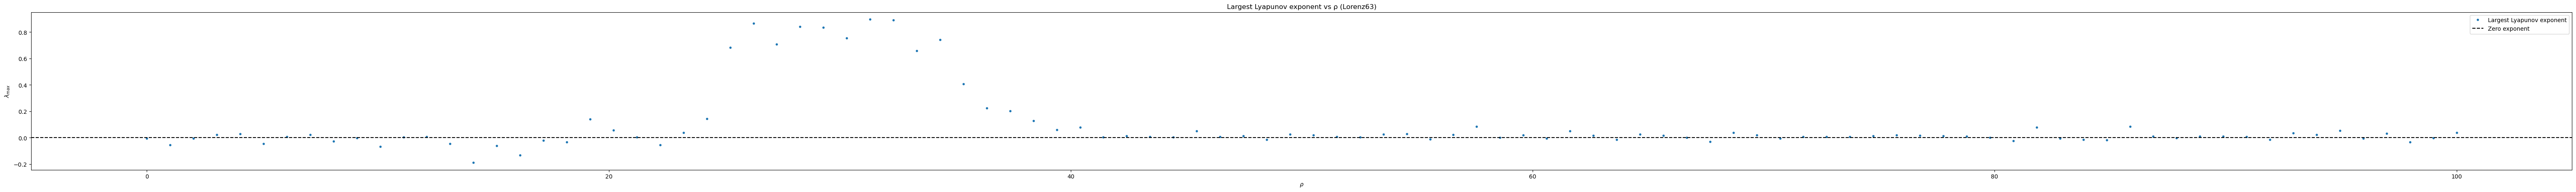

In [20]:
# Plot Lyapunov exponent vs rho
plt.figure(figsize=(80,5))
plt.plot(rho_values, lambda_max_list, '.', label='Largest Lyapunov exponent')
plt.axhline(0, color='k', linestyle='--', label='Zero exponent')
plt.xlabel(r'$\rho$')
plt.ylabel(r'$\lambda_{max}$')
plt.title('Largest Lyapunov exponent vs ρ (Lorenz63)')
plt.legend()
plt.show()


### 3 Dimensions

In [ ]:
import nolds
df = ds1.to_dataframe()  # does not save by default
# # Feature Extraction
# lyap = nolds.lyap_r(df['x'])
# import nolds
lyap = nolds.lyap_r(df['x'], emb_dim=3, min_tsep=1)

print("Lyapunov Exponent:", lyap)